# Notebook 06 — Greeks and Sensitivities

**quant-desk-toolkit** · github.com/hyun-quant/quant-desk-toolkit

---

Greeks measure how the value of an instrument changes with market variables. This notebook implements bump-and-reprice for the full toolkit.

1. **Curve bumping**: parallel and point bumps to the OIS curve
2. **IRS Greeks**: DV01, duration, convexity, bucketed DV01
3. **Bond Greeks**: DV01, modified duration, convexity (positive), P&L attribution
4. **Hedge construction**: DV01-neutral hedge portfolio
5. **CVA IR DV01**: sensitivity of CVA to a parallel rate shift

**Prerequisites**: all prior pickles
**Outputs**: `greeks_results.pkl`


## 0. Setup

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from curve_factory import Curve
from instruments import InterestRateSwap, Bond
from simulator import HullWhiteSimulator, MonteCarloEngine
from exposure import ExposureEngine, NettingSet
from xva import XVAEngine

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

with open('curves.pkl',    'rb') as f: cd   = pickle.load(f)
with open('instruments.pkl', 'rb') as f: inst = pickle.load(f)
with open('mc_results.pkl', 'rb') as f: mc   = pickle.load(f)
with open('exposure_results.pkl', 'rb') as f: exp = pickle.load(f)
with open('xva_results.pkl', 'rb') as f: xva_data = pickle.load(f)

ois_curve  = cd['ois_curve']
sofr_curve = cd['sofr_curve']
time_grid  = mc['time_grid']
HW_A, HW_SIGMA = mc['hw_a'], mc['hw_sigma']
hw_sim = HullWhiteSimulator(a=HW_A, sigma=HW_SIGMA, curve=ois_curve)

print('All pickles loaded.')

All pickles loaded.


---
## 1. Curve Bumping Mechanics

Greeks are computed via **bump-and-reprice**: shift the yield curve by a small amount $h$, reprice the instrument, and compute the finite difference:

$$DV01 \approx \frac{V(r+h) - V(r-h)}{2h} \quad \text{(central difference)}$$

For a **parallel bump**, all zero rates shift uniformly. For a **point bump**, only the rate at a specific tenor node shifts.

We implement curve bumping by reconstructing a `Curve` object from bumped zero rates.


In [52]:
def bump_curve_parallel(curve: Curve, bump_bps: float) -> Curve:
    """Shift all zero rates by bump_bps basis points, recompute DFs."""
    bump        = bump_bps / 10000.0
    bumped_zero = curve.zero_rates + bump
    bumped_dfs  = np.exp(-bumped_zero * curve.tenors)
    # Ensure P(0,0) = 1
    bumped_dfs[0] = 1.0
    return Curve(curve.tenors, bumped_dfs, label=curve.label + f'_+{bump_bps}bp')

def bump_curve_at_tenor(curve: Curve, target_tenor: float, bump_bps: float) -> Curve:
    """Shift the zero rate at the nearest pillar to target_tenor."""
    bump       = bump_bps / 1000.0
    zero_bumped = curve.zero_rates.copy()
    idx         = np.argmin(np.abs(curve.tenors - target_tenor))
    zero_bumped[idx] += bump
    dfs_bumped  = np.where(
        curve.tenors > 0,
        np.exp(-zero_bumped * curve.tenors),
        1.0
    )
    dfs_bumped[0] = 1.0
    return Curve(curve.tenors, dfs_bumped, label=curve.label + f'_bump_{target_tenor}Y')

# Quick sanity check
ois_up = bump_curve_parallel(ois_curve, +1)
ois_dn = bump_curve_parallel(ois_curve, -1)

print('Parallel bump sanity check (5Y zero rate):')
print(f'  Base    : {float(ois_curve.zero_rate(5.0))*100:.4f}%')
print(f'  +1bp    : {float(ois_up.zero_rate(5.0))*100:.4f}%')
print(f'  -1bp    : {float(ois_dn.zero_rate(5.0))*100:.4f}%')

Parallel bump sanity check (5Y zero rate):
  Base    : 4.2668%
  +1bp    : 4.2768%
  -1bp    : 4.2568%


---
## 2. IRS Greeks

For a **payer IRS**:
- **DV01** > 0: rising rates increase PV (floating leg grows, fixed leg unchanged)
- **Duration** < 0: behaves like a short bond (payer pays fixed coupon → opposite of bond holder)
- **Convexity**: small positive convexity from the swap structure


In [53]:
swap = InterestRateSwap(
    notional          = inst['swap_notional'],
    fixed_rate        = inst['swap_fixed_rate'],
    tenor             = inst['swap_tenor'],
    payment_frequency = inst['swap_pay_freq'],
    float_frequency   = inst['swap_float_freq'],
    payer             = inst['swap_payer'],
)

BUMP = 1.0   # 1bp

# Parallel DV01 (central difference)
pv_up  = swap.pv(bump_curve_parallel(ois_curve, +BUMP), sofr_curve)['pv_net']
pv_dn  = swap.pv(bump_curve_parallel(ois_curve, -BUMP), sofr_curve)['pv_net']
pv_base = swap.pv(ois_curve, sofr_curve)['pv_net']

dv01_parallel  = (pv_up - pv_dn) / 2
duration       = dv01_parallel / (-pv_base / 10000) if pv_base != 0 else 0
convexity      = (pv_up + pv_dn - 2*pv_base) / (BUMP/10000)**2 / inst['swap_notional']

print('IRS Greeks (5Y Payer, $10mm, central difference):')
print(f'  Base PV           : ${pv_base:>12,.2f}')
print(f'  Parallel DV01     : ${dv01_parallel:>12,.2f}  per 1bp')
print(f'  Dollar Duration   : ${dv01_parallel*100:>12,.2f}  per 1%')
print(f'  Convexity (/$mm)  : {convexity:>12.4f}')

IRS Greeks (5Y Payer, $10mm, central difference):
  Base PV           : $        0.00
  Parallel DV01     : $       48.91  per 1bp
  Dollar Duration   : $    4,891.35  per 1%
  Convexity (/$mm)  :      -0.2420


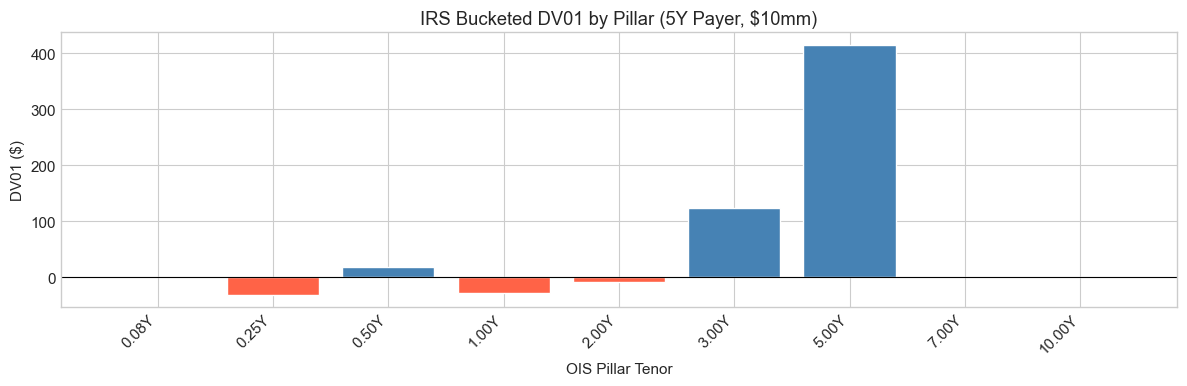

Sum of bucketed DV01: $487.90  vs parallel DV01: $48.91


In [54]:
# Bucketed DV01 — sensitivity to each pillar
pillar_tenors = ois_curve.tenors[1:]   # skip T=0
dv01_bucketed = []
for t in pillar_tenors:
    ois_bump = bump_curve_at_tenor(ois_curve, t, +BUMP)
    pv_b = swap.pv(ois_bump, sofr_curve)['pv_net']
    dv01_bucketed.append(pv_b - pv_base)

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['tomato' if d < 0 else 'steelblue' for d in dv01_bucketed]
ax.bar(range(len(pillar_tenors)), dv01_bucketed, color=colors, edgecolor='white')
ax.set_xticks(range(len(pillar_tenors)))
ax.set_xticklabels([f'{t:.2f}Y' for t in pillar_tenors], rotation=45, ha='right')
ax.axhline(y=0, color='black', lw=0.8)
ax.set_title('IRS Bucketed DV01 by Pillar (5Y Payer, $10mm)')
ax.set_xlabel('OIS Pillar Tenor'); ax.set_ylabel('DV01 ($)')
plt.tight_layout(); plt.savefig('nb06_irs_dv01.png', dpi=120, bbox_inches='tight'); plt.show()
print(f'Sum of bucketed DV01: ${sum(dv01_bucketed):,.2f}  vs parallel DV01: ${dv01_parallel:,.2f}')

---
## 3. Bond Greeks

For a bond:
- **DV01** < 0: rising rates decrease bond price
- **Modified Duration** > 0: $D_{mod} = -dP/dy / P$
- **Convexity** > 0: the DV01 effect is asymmetric — bonds gain more from rate decreases than they lose from rate increases (positive convexity)


In [55]:
bond = Bond(
    face_value       = inst['bond_face'],
    coupon_rate      = inst['bond_coupon'],
    maturity         = inst['bond_maturity'],
    coupon_frequency = inst['bond_freq'],
)

price_base = bond.dirty_price(ois_curve)
price_up   = bond.dirty_price(bump_curve_parallel(ois_curve, +BUMP))
price_dn   = bond.dirty_price(bump_curve_parallel(ois_curve, -BUMP))

dv01_bond     = (price_up - price_dn) / 2
mod_duration  = -dv01_bond * 10000 / price_base          # duration in years
conv_bond     = (price_up + price_dn - 2*price_base) / (BUMP/10000)**2 / price_base

print('Bond Greeks (10Y 4% Semi-Annual, $1mm):')
print(f'  Dirty price       : ${price_base:>12,.2f}')
print(f'  DV01 (central)    : ${dv01_bond:>12,.2f}  per 1bp  (negative = falls when rates rise)')
print(f'  Modified Duration : {mod_duration:>12.4f}  years')
print(f'  Dollar Duration   : ${-dv01_bond*100/price_base*price_base:>12,.2f}  per 1%')
print(f'  Convexity         : {conv_bond*100:>12.4f}  (positive = benefits from rate moves)')

Bond Greeks (10Y 4% Semi-Annual, $1mm):
  Dirty price       : $  992,424.47
  DV01 (central)    : $     -828.51  per 1bp  (negative = falls when rates rise)
  Modified Duration :       8.3483  years
  Dollar Duration   : $   82,850.82  per 1%
  Convexity         :    7804.1086  (positive = benefits from rate moves)


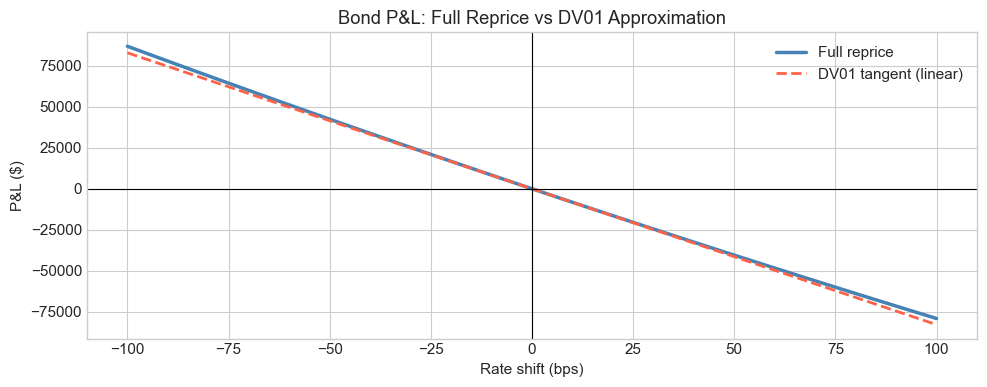

Gap between curves = convexity P&L.  Bond gains more than it loses (positive convexity).


In [56]:
# P&L attribution: DV01 tangent vs full reprice
shifts_bps = np.linspace(-100, 100, 100)
pnl_full   = []
pnl_dv01   = []

for h in shifts_bps:
    c_bumped = bump_curve_parallel(ois_curve, h)
    pnl_full.append(bond.dirty_price(c_bumped) - price_base)
    pnl_dv01.append(dv01_bond * h)   # linear approximation

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(shifts_bps, pnl_full, lw=2.5, color='steelblue', label='Full reprice')
ax.plot(shifts_bps, pnl_dv01, lw=2,   color='tomato', ls='--', label='DV01 tangent (linear)')
ax.axhline(y=0, color='black', lw=0.8); ax.axvline(x=0, color='black', lw=0.8)
ax.set_title('Bond P&L: Full Reprice vs DV01 Approximation'); ax.legend()
ax.set_xlabel('Rate shift (bps)'); ax.set_ylabel('P&L ($)')
plt.tight_layout(); plt.savefig('nb06_bond_pnl.png', dpi=120, bbox_inches='tight'); plt.show()
print('Gap between curves = convexity P&L.  Bond gains more than it loses (positive convexity).')

---
## 4. Hedge Portfolio Construction

A **DV01-neutral hedge** eliminates first-order rate risk. Given the IRS DV01 and bond DV01, the hedge ratio is:

$$h = -\frac{DV01_{IRS}}{DV01_{bond}}$$

We express the hedge as a bond notional that offsets the IRS DV01.


In [57]:
# DV01 per unit notional
dv01_irs_per_unit  = dv01_parallel / inst['swap_notional']
dv01_bond_per_unit = dv01_bond     / inst['bond_face']

# Hedge ratio: how much bond face value offsets $10mm IRS
hedge_notional = -dv01_parallel / dv01_bond_per_unit

print('DV01-Neutral Hedge Construction:')
print(f'  IRS DV01 (total)      : ${dv01_parallel:>12,.2f}  per 1bp')
print(f'  Bond DV01 per $1mm    : ${dv01_bond_per_unit*1e6:>12,.2f}  per 1bp')
print(f'  Hedge notional        : ${hedge_notional:>12,.0f}  bonds to offset IRS DV01')
print()
print(f'Verification (hedged portfolio DV01):')
hedged_dv01 = dv01_parallel + dv01_bond_per_unit * hedge_notional
print(f'  IRS DV01              : ${dv01_parallel:>12,.2f}')
print(f'  Bond DV01 (hedged)    : ${dv01_bond_per_unit * hedge_notional:>12,.2f}')
print(f'  Net DV01              : ${hedged_dv01:>12,.4f}  (≈ 0, hedged)')

DV01-Neutral Hedge Construction:
  IRS DV01 (total)      : $       48.91  per 1bp
  Bond DV01 per $1mm    : $     -828.51  per 1bp
  Hedge notional        : $      59,038  bonds to offset IRS DV01

Verification (hedged portfolio DV01):
  IRS DV01              : $       48.91
  Bond DV01 (hedged)    : $      -48.91
  Net DV01              : $      0.0000  (≈ 0, hedged)


---
## 5. CVA IR DV01

The CVA depends on the exposure profile EE(t), which in turn depends on the rate paths. A parallel rate shift changes both the EE and the discount factors used in the CVA integral, requiring a **full Monte Carlo re-run**.

This is expensive but necessary — there is no closed-form shortcut for CVA IR DV01.

**Procedure**:
1. Run MC with base OIS curve → base EE → base CVA
2. Run MC with bumped OIS curve → bumped EE → bumped CVA
3. CVA IR DV01 = bumped CVA − base CVA


In [58]:
from xva import CVAEngine

N_PATHS_SENS = 1000   # fewer paths for speed

def run_cva(ois_c, bump_bps=0.0):
    """Run MC and compute CVA for a given OIS curve."""
    c = bump_curve_parallel(ois_c, bump_bps) if bump_bps != 0 else ois_c
    hw = HullWhiteSimulator(a=HW_A, sigma=HW_SIGMA, curve=c)
    mc = MonteCarloEngine(hw_simulator=hw)
    res = mc.run(time_grid, n_paths=N_PATHS_SENS, use_antithetic=True)

    swap_local = InterestRateSwap(
        notional=inst['swap_notional'], fixed_rate=inst['swap_fixed_rate'],
        tenor=inst['swap_tenor'], payment_frequency=inst['swap_pay_freq'],
        float_frequency=inst['swap_float_freq'], payer=inst['swap_payer'],
    )
    payment_dates = swap_local._fixed_payment_dates()
    exp_eng = ExposureEngine(res, hw)
    val_fn  = exp_eng.irs_valuator(swap_local.fixed_rate, payment_dates, swap_local.notional, swap_local.payer)
    ns      = NettingSet(name='IRS', trade_valuators=[val_fn])
    summary = exp_eng.exposure_summary(ns)

    cva_eng = CVAEngine(
        ee_profile               = summary['EE'],
        time_grid                = time_grid,
        counterparty_tenors      = xva_data['cpty_tenors'],
        counterparty_hazard_rates= xva_data['cpty_hazard_rates'],
        recovery_rate            = 0.40,
    )
    return cva_eng.compute(), summary['EE']

print('Running base CVA MC...')
cva_base, ee_base = run_cva(ois_curve, 0.0)
print(f'  Base CVA = ${cva_base:,.0f}')

print('Running bumped CVA MC (+1bp)...')
cva_up, ee_up = run_cva(ois_curve, +1.0)
print(f'  Bumped CVA = ${cva_up:,.0f}')

cva_ir_dv01 = cva_up - cva_base
print(f'  CVA IR DV01 = ${cva_ir_dv01:,.2f}  per 1bp parallel shift')
print(f'  Sign: {"positive" if cva_ir_dv01 > 0 else "negative"} (rising rates {"increase" if cva_ir_dv01 > 0 else "decrease"} CVA)')

Running base CVA MC...
  Base CVA = $3,008
Running bumped CVA MC (+1bp)...
  Bumped CVA = $2,859
  CVA IR DV01 = $-148.84  per 1bp parallel shift
  Sign: negative (rising rates decrease CVA)


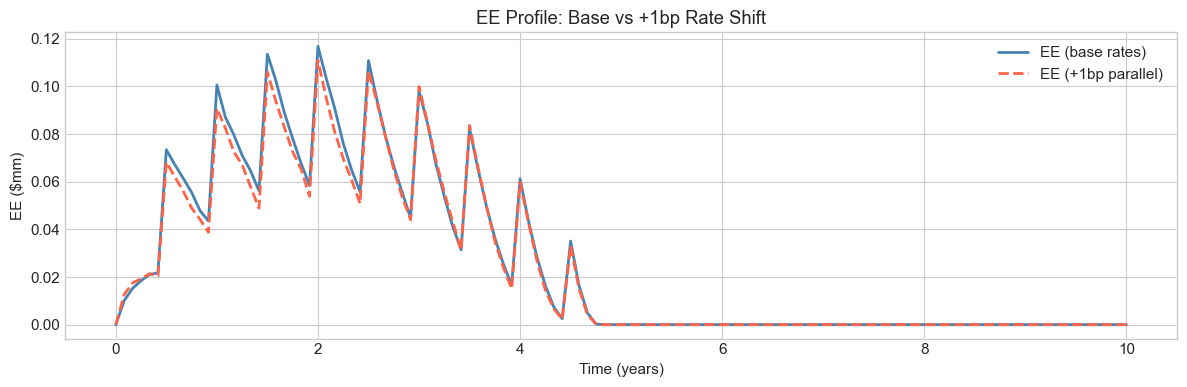

In [59]:
# Compare EE profiles: base vs bumped
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_grid, ee_base/1e6, lw=2, color='steelblue', label='EE (base rates)')
ax.plot(time_grid, ee_up/1e6,   lw=2, ls='--', color='tomato', label='EE (+1bp parallel)')
ax.set_title('EE Profile: Base vs +1bp Rate Shift')
ax.set_xlabel('Time (years)'); ax.set_ylabel('EE ($mm)'); ax.legend()
plt.tight_layout(); plt.savefig('nb06_cva_dv01.png', dpi=120, bbox_inches='tight'); plt.show()

---
## 6. Consolidated Risk Report

In [60]:
print('=' * 60)
print('  CONSOLIDATED RISK REPORT — 5Y Payer IRS, $10mm')
print('=' * 60)
print()
print('INSTRUMENT:')
print(f'  Fixed rate          : {inst["swap_fixed_rate"]*100:.4f}%')
print(f'  Par rate            : {inst["swap_par_rate"]*100:.4f}%')
print(f'  Current PV          : ${pv_base:>12,.0f}')
print()
print('IR GREEKS (parallel bump):')
print(f'  DV01                : ${dv01_parallel:>12,.2f}  per bp')
print(f'  Dollar Duration     : ${dv01_parallel*100:>12,.0f}  per 1%')
print(f'  Convexity (/$mm)    : {convexity*1e6:>12.2f}')
print()
print('EXPOSURE:')
ee_peak = exp['EE'].max()
pfe_peak = exp['PFE_95'].max()
epe = exp['EPE']
print(f'  Peak EE             : ${ee_peak:>12,.0f}')
print(f'  Peak PFE (95%)      : ${pfe_peak:>12,.0f}')
print(f'  EPE                 : ${epe:>12,.0f}')
print()
print('XVA:')
xva = xva_data['xva']
print(f'  CVA                 : ${xva["CVA"]:>12,.0f}')
print(f'  DVA                 : ${xva["DVA"]:>12,.0f}')
print(f'  FVA                 : ${xva["FVA"]:>12,.0f}')
print(f'  MVA                 : ${xva["MVA"]:>12,.0f}')
print(f'  Total XVA           : ${xva["total_XVA"]:>12,.0f}')
print(f'  CS01                : ${xva["CS01"]:>12,.2f}')
print(f'  CVA IR DV01         : ${cva_ir_dv01:>12,.2f}')
print()
print('=' * 60)

  CONSOLIDATED RISK REPORT — 5Y Payer IRS, $10mm

INSTRUMENT:
  Fixed rate          : 4.5608%
  Par rate            : 4.5608%
  Current PV          : $           0

IR GREEKS (parallel bump):
  DV01                : $       48.91  per bp
  Dollar Duration     : $       4,891  per 1%
  Convexity (/$mm)    :   -242029.46

EXPOSURE:
  Peak EE             : $     106,073
  Peak PFE (95%)      : $     563,799
  EPE                 : $      24,628

XVA:
  CVA                 : $       2,746
  DVA                 : $      -9,671
  FVA                 : $      -5,047
  MVA                 : $       6,114
  Total XVA           : $      -5,859
  CS01                : $       21.90
  CVA IR DV01         : $     -148.84



---
## 7. Save Outputs

In [61]:
greeks_results = {
    'dv01_irs_parallel'  : dv01_parallel,
    'dv01_irs_bucketed'  : list(zip(pillar_tenors.tolist(), dv01_bucketed)),
    'duration_irs'       : duration,
    'convexity_irs'      : convexity,
    'dv01_bond'          : dv01_bond,
    'mod_duration_bond'  : mod_duration,
    'convexity_bond'     : conv_bond,
    'hedge_notional'     : hedge_notional,
    'cva_ir_dv01'        : cva_ir_dv01,
    'cva_base'           : cva_base,
    'ee_base'            : ee_base,
}
with open('greeks_results.pkl', 'wb') as f:
    pickle.dump(greeks_results, f)
print('Saved greeks_results.pkl')
print()
print('All 6 notebooks complete. Full pickle chain:')
print('  nb01 → curves.pkl, instruments.pkl')
print('  nb02 → mc_results.pkl')
print('  nb03 → exposure_results.pkl, xva_results.pkl')
print('  nb04 → saccr_results.pkl')
print('  nb05 → margin_results.pkl')
print('  nb06 → greeks_results.pkl')

Saved greeks_results.pkl

All 6 notebooks complete. Full pickle chain:
  nb01 → curves.pkl, instruments.pkl
  nb02 → mc_results.pkl
  nb03 → exposure_results.pkl, xva_results.pkl
  nb04 → saccr_results.pkl
  nb05 → margin_results.pkl
  nb06 → greeks_results.pkl
